In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import scipy.stats as stats
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error, mean_absolute_error,mean_absolute_percentage_error
from sklearn.ensemble import RandomForestRegressor
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv(r'C:\Users\DELL\Downloads\archive (28)\rainfall_raw.csv')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1781 entries, 0 to 1780
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   datetime          1781 non-null   object 
 1   temp              1758 non-null   float64
 2   dew               1781 non-null   float64
 3   humidity          1781 non-null   float64
 4   sealevelpressure  1781 non-null   float64
 5   winddir           1781 non-null   float64
 6   solarradiation    1781 non-null   float64
 7   windspeed         1781 non-null   float64
 8   precipprob        1781 non-null   int64  
 9   preciptype        1781 non-null   int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 139.3+ KB


**CHƯƠNG 3: TIỀN XỬ LÝ DỮ LIỆU**

**3.1 Tổng quan bộ dữ liệu**

In [3]:
df.head()

,datetime,temp,dew,humidity,sealevelpressure,winddir,solarradiation,windspeed,precipprob,preciptype
0,1/1/2016,28.4,11.9,37.8,1016.4,147.5,216.1,16.6,0,0
1,2/1/2016,26.8,13.0,44.8,1017.2,110.3,215.7,16.6,0,0
2,3/1/2016,25.5,14.6,52.8,1015.7,145.3,221.1,18.4,0,0
3,4/1/2016,26.4,13.1,46.6,1015.3,126.9,216.2,16.6,0,0
4,5/1/2016,27.1,13.5,44.9,1014.4,125.5,208.1,16.6,0,0


**3.2 Chỉnh dạng dữ liệu**

Chuẩn hóa biến datetime và chuyển nó thành index

In [4]:
# Chuyển cột 'datetime' sang kiểu datetime
df['datetime'] = pd.to_datetime(df['datetime'], format='mixed', dayfirst=True, errors='coerce')

In [5]:
# Đặt cột 'datetime' làm index
df = df.set_index('datetime').sort_index()

In [6]:
df.head()

,temp,dew,humidity,sealevelpressure,winddir,solarradiation,windspeed,precipprob,preciptype
datetime,,,,,,,,,
2016-01-01,28.4,11.9,37.8,1016.4,147.5,216.1,16.6,0,0
2016-01-02,26.8,13.0,44.8,1017.2,110.3,215.7,16.6,0,0
2016-01-03,25.5,14.6,52.8,1015.7,145.3,221.1,18.4,0,0
2016-01-04,26.4,13.1,46.6,1015.3,126.9,216.2,16.6,0,0
2016-01-05,27.1,13.5,44.9,1014.4,125.5,208.1,16.6,0,0


**3.3 Xử lý Missing Values**

Kiểm tra xem các biến có Missing Values hay không

In [7]:
missing_df = df.isnull().sum().reset_index()
missing_df.columns = ['Tên biến', 'Số lượng missing values']
print(missing_df.to_string(index=False))

        Tên biến  Số lượng missing values
            temp                       23
             dew                        0
        humidity                        0
sealevelpressure                        0
         winddir                        0
  solarradiation                        0
       windspeed                        0
      precipprob                        0
      preciptype                        0


Kiểm tra tương quan giữa biến temp với các biến khác xem có tương quan mạnh hay không để xử lý missing values

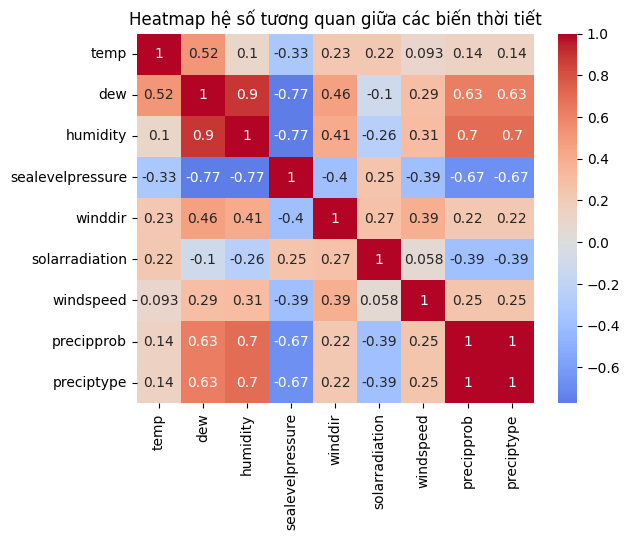

In [8]:
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Heatmap hệ số tương quan giữa các biến thời tiết')
plt.show()

In [9]:
corr_with_temp = df.corr(method='pearson')['temp'].sort_values(ascending=False)
print(corr_with_temp)


temp                1.000000
dew                 0.519328
winddir             0.228947
solarradiation      0.219635
preciptype          0.135191
precipprob          0.135191
humidity            0.100350
windspeed           0.093398
sealevelpressure   -0.325343
Name: temp, dtype: float64


Nhận thấy rằng các biến không có tương quan cao với biến Temp nên ta không thể điền giá trị null bằng các giá trị trung bình theo từng biến

Ta quyết định sẽ điền các giá trị còn thiếu bằng phương pháp nội suy. Cụ thể là trung bình cộng của ngày trước và sau, do rằng dữ liệu thời gian có xu thế tăng hoặc giảm trong các ngày liền kề nhau

In [10]:
df['temp'] = df['temp'].interpolate(method='time')

In [11]:
missing_df = df.isnull().sum().reset_index()
missing_df.columns = ['Tên biến', 'Số lượng missing values']
print(missing_df.to_string(index=False))

        Tên biến  Số lượng missing values
            temp                        0
             dew                        0
        humidity                        0
sealevelpressure                        0
         winddir                        0
  solarradiation                        0
       windspeed                        0
      precipprob                        0
      preciptype                        0


**3.4 EDA**

In [12]:
# Xem nhiệt độ trung bình của các tháng qua từng năm

df['year'] = df.index.year
df['month'] = df.index.month

# Tính trung bình nhiệt độ theo năm–tháng
pivot_table = df.pivot_table(values='temp', index='year', columns='month', aggfunc='mean')
pivot_table.head()


plt.figure(figsize=(10, 6), dpi=1200)
sns.heatmap(pivot_table, cmap='coolwarm', annot=True, fmt=".1f")
plt.title("Nhiệt độ trung bình của mỗi tháng qua từng năm")
plt.xlabel("Tháng")
plt.ylabel("Năm")
plt.show()

In [13]:
# Xem xu hướng trung bình trượt (Rolling Mean)

day = 30

df[f'temp_{day}_mean'] = df['temp'].rolling(window=day).mean()

plt.figure(figsize=(12,5), dpi=1200)
plt.plot(df['temp'], alpha=0.5, label='Nhiệt độ')
plt.plot(df[f'temp_{day}_mean'], color='red', label=f'Trung bình {day} ngày')
plt.legend()
plt.title(f'Nhiệt độ trung bình trượt {day} ngày')
plt.show()
df = df.drop(columns=[f'temp_{day}_mean'])

<Axes: xlabel='datetime'>

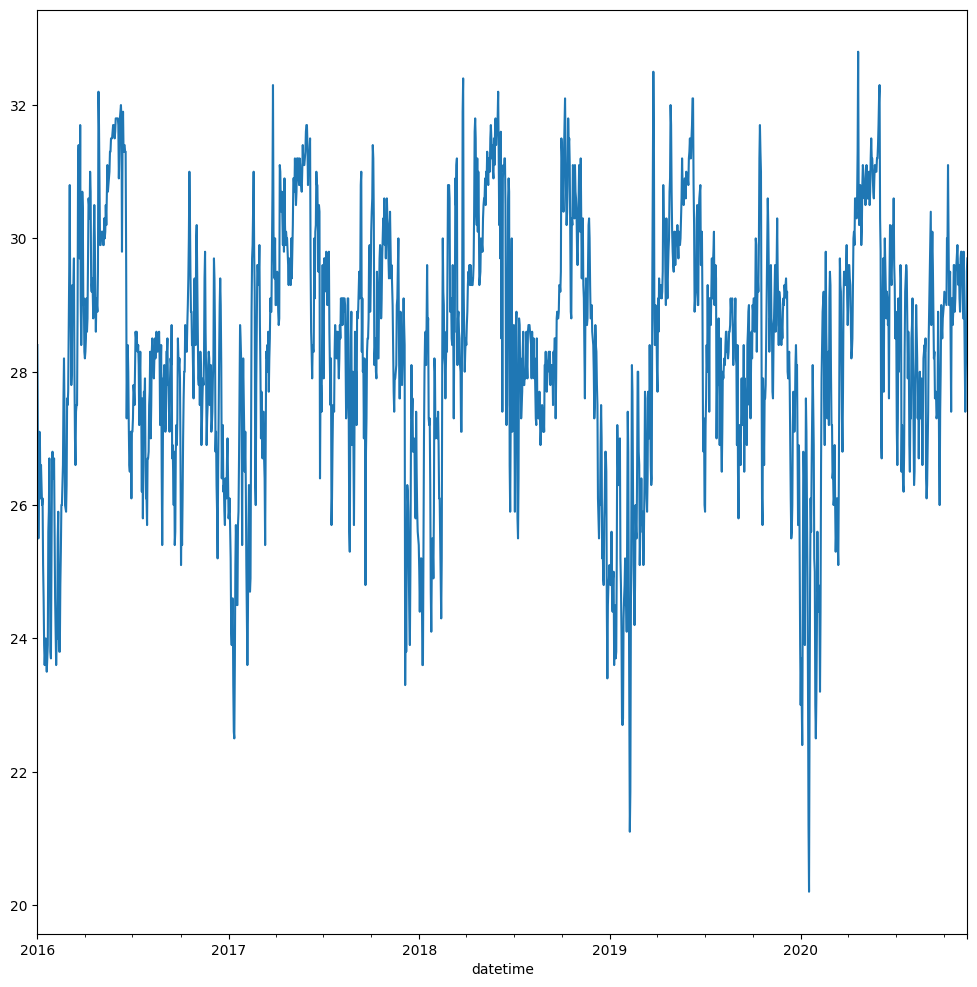

In [14]:
df['temp'].plot(figsize = (12,12))

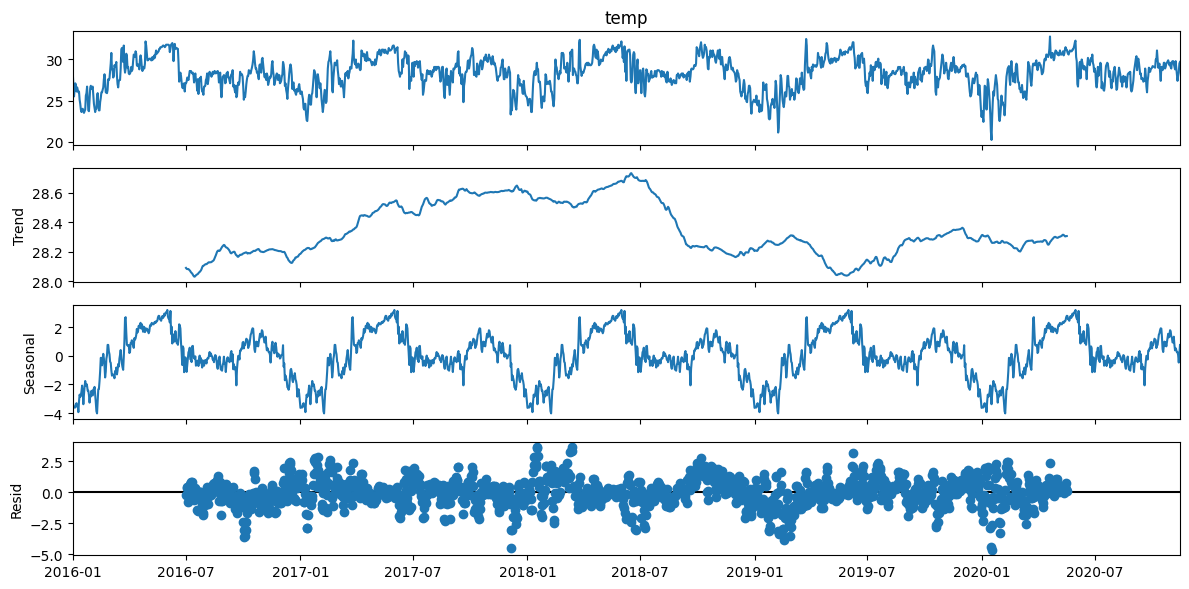

In [15]:
result = seasonal_decompose(df['temp'], model='additive', period=365)

# Vẽ biểu đồ decomposition
fig = result.plot()
fig.set_size_inches(12, 6)
plt.tight_layout()
plt.show()

**CHƯƠNG 4**

Kiểm tra tính dừng của dữ liệu

In [16]:
data = df[['temp']].copy()
data.head()

,temp
datetime,
2016-01-01,28.4
2016-01-02,26.8
2016-01-03,25.5
2016-01-04,26.4
2016-01-05,27.1


In [17]:
result = adfuller(data["temp"])
print(f"ADF Test Stat: {result[0]}")
print(f"p-value: {result[1]}")

if result[1] < 0.05:
    print("Chuỗi có tính dừng !")
else:
    print("Chuỗi không có tính dừng, cần lấy sai phân")

ADF Test Stat: -4.460307805428925
p-value: 0.00023179367260907124
Chuỗi có tính dừng !


Sau khi đã kiểm định, giá trị p-value xấp xỉ bằng 0 và nhỏ hơn 0.05 => Chuỗi có tính dừng, ổn định

Vì chuỗi trên đã có tính dừng nên ta không cần lấy sai phân nữa, cho nên lúc này giá trị d trong bộ tham số của chúng ta là bằng 0

Xác định tham số p và q

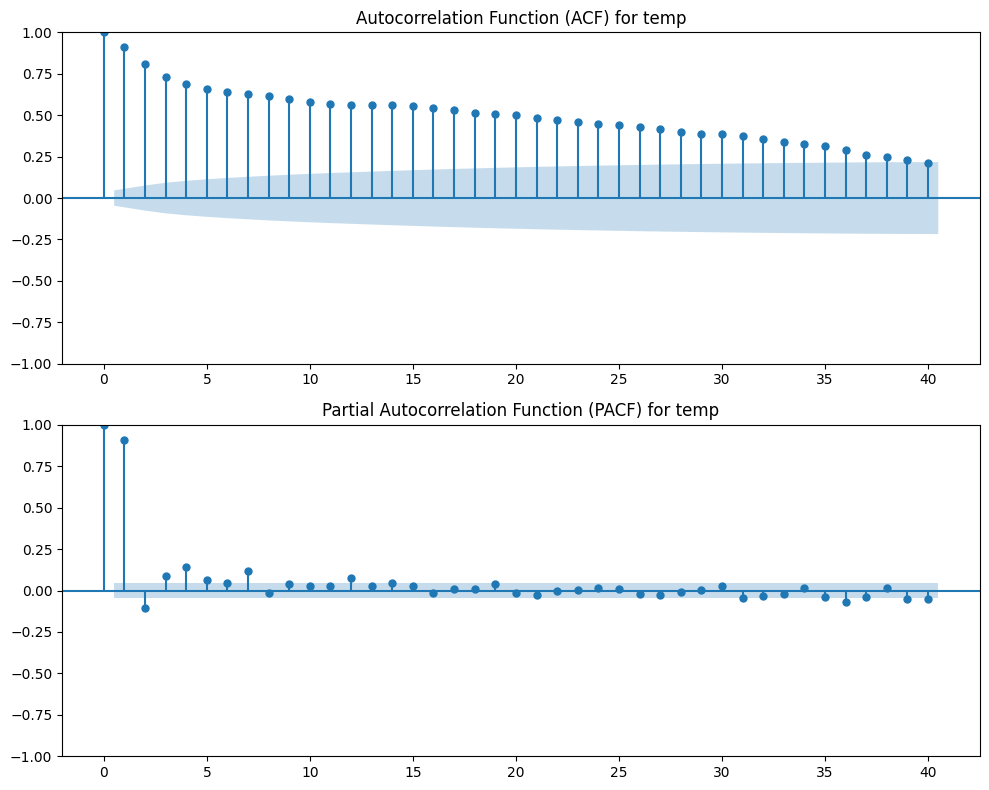

In [18]:
# Vẽ biểu đồ ACF và PACF
fig, ax = plt.subplots(2, 1, figsize=(10, 8))

plot_acf(data, ax=ax[0], lags=40)
ax[0].set_title('Autocorrelation Function (ACF) for temp')

plot_pacf(data, ax=ax[1], lags=40, method='ywm')
ax[1].set_title('Partial Autocorrelation Function (PACF) for temp')

plt.tight_layout()
plt.show()

Đối với biểu đồ ACF, các điểm lags giảm từ từ không đột ngột nên ta khó có thể xác định được điểm cắt

Biểu đồ PACF có vẻ như có điểm cắt tại lag 1 nên ta có thể xem xét

Tìm bộ tham số tối ưu nhất

In [19]:
# Xác định không gian tham số
p_range = range(0, 4)
d = 0
q_range = range(0, 4)

results = []

# Thử tất cả các tổ hợp (p,d,q)
for p in p_range:
    for q in q_range:
        try:
            model = ARIMA(data, order=(p, d, q))
            fitted = model.fit()
            results.append({
                'Bộ tham số (p,d,q)': f'({p},{d},{q})',
                'AIC': fitted.aic,
                'BIC': fitted.bic
            })
        except Exception:
            continue

# Tạo bảng kết quả và chọn mô hình tối ưu
results_df = pd.DataFrame(results).sort_values('AIC').reset_index(drop=True)
best_row = results_df.iloc[0]

# Hiển thị bảng kết quả
print("Bảng kết quả các bộ tham số của mô hình ARIMA")
print(results_df.to_string(index=False))

# Hiển thị mô hình tối ưu
print(f"Mô hình tối ưu: ARIMA{best_row['Bộ tham số (p,d,q)']}")
print(f"Chỉ số AIC: {best_row['AIC']:.2f}   | Chỉ số BIC: {best_row['BIC']:.2f}")

Bảng kết quả các bộ tham số của mô hình ARIMA
Bộ tham số (p,d,q)         AIC         BIC
           (2,0,3) 4247.143227 4285.537739
           (3,0,3) 4249.125830 4293.005272
           (3,0,2) 4253.237841 4291.632353
           (3,0,1) 4253.348789 4286.258371
           (2,0,2) 4264.325229 4297.234811
           (1,0,3) 4266.025137 4298.934719
           (3,0,0) 4318.223184 4345.647835
           (1,0,2) 4324.693458 4352.118110
           (1,0,1) 4325.906347 4347.846068
           (2,0,1) 4327.242507 4354.667159
           (2,0,0) 4328.934106 4350.873827
           (1,0,0) 4347.536480 4363.991271
           (0,0,3) 4783.239106 4810.663757
           (0,0,2) 5099.664158 5121.603879
           (0,0,1) 5880.069350 5896.524140
           (0,0,0) 7454.076283 7465.046144
Mô hình tối ưu: ARIMA(2,0,3)
Chỉ số AIC: 4247.14   | Chỉ số BIC: 4285.54


**HUẤN LUYỆN MÔ HÌNH**

**Mô hình ARIMA (2,0,3)**

In [20]:
# Chia bộ dữ liệu theo tỉ lệ 80/20

print("BƯỚC 5.1: CHIA DỮ LIỆU TRAIN/TEST")

# Chia dữ liệu (theo thời gian, không shuffle)
train_data, test_data = train_test_split(data, test_size = 0.2, shuffle = False)

print(f"\nKích thước dữ liệu:")
print(f"- Tổng số quan sát: {len(data)}")
print(f"- Training set: {len(train_data)} mẫu ({len(train_data)/len(data)*100:.1f}%)")
print(f"- Test set: {len(test_data)} mẫu ({len(test_data)/len(data)*100:.1f}%)")

BƯỚC 5.1: CHIA DỮ LIỆU TRAIN/TEST

Kích thước dữ liệu:
- Tổng số quan sát: 1781
- Training set: 1424 mẫu (80.0%)
- Test set: 357 mẫu (20.0%)


In [21]:
print("BƯỚC 5.2: HUẤN LUYỆN MÔ HÌNH ARIMA (BỘ THAM SỐ TỐI ƯU)")

# Lấy bộ tham số tối ưu từ ta đã có kết quả ở chương 4 trước đó
best_params_str = best_row['Bộ tham số (p,d,q)']
best_params = tuple(map(int, best_params_str.strip('()').split(',')))

print(f"\nĐang huấn luyện mô hình ARIMA{best_params}...")

# Fit mô hình ARIMA với dữ liệu huấn luyện
final_model = ARIMA(train_data, order=best_params)
final_fitted = final_model.fit()

# Hiển thị thông tin mô hình
print(f"Các thông số của mô hình ARIMA{best_params}:")
print(final_fitted.summary())

# Lưu lại mô hình đã fit để dùng cho bước Rolling Forecast
best_params = best_params  

BƯỚC 5.2: HUẤN LUYỆN MÔ HÌNH ARIMA (BỘ THAM SỐ TỐI ƯU)

Đang huấn luyện mô hình ARIMA(2, 0, 3)...
Các thông số của mô hình ARIMA(2, 0, 3):
                               SARIMAX Results                                
Dep. Variable:                   temp   No. Observations:                 1424
Model:                 ARIMA(2, 0, 3)   Log Likelihood               -1696.321
Date:                Fri, 07 Nov 2025   AIC                           3406.642
Time:                        09:36:00   BIC                           3443.470
Sample:                    01-01-2016   HQIC                          3420.397
                         - 11-24-2019                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         28.3368      0.456     62.160      0.000      27.443     

In [22]:
print('Bước 5.3. Thực hiện Rolling Forecast')
preds = []
model = final_fitted

for t in range(len(test_data)):
    yhat = model.forecast()[0]  # Dự báo một bước
    preds.append(yhat)
    model = model.append([test_data.iloc[t]], refit=False)  # Cập nhật dữ liệu

predictions = pd.Series(preds, index=test_data.index)
print("Rolling Forecast đã hoàn tất")

Bước 5.3. Thực hiện Rolling Forecast
Rolling Forecast đã hoàn tất


In [23]:
mse = mean_squared_error(test_data, predictions)
rmse = np.sqrt(mse)
mae = mean_absolute_error(test_data, predictions)
mape = mean_absolute_percentage_error(test_data, predictions) * 100
r2 = r2_score(test_data, predictions)


print("Bước 5.4 Đánh giá mô hình")
print(f"Mean Squared Error (MSE):  {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f} °C")
print(f"Mean Absolute Error (MAE): {mae:.4f} °C")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")
print(f"R² (Coefficient of Determination): {r2:.4f}")

Bước 5.4 Đánh giá mô hình
Mean Squared Error (MSE):  0.6193
Root Mean Squared Error (RMSE): 0.7870 °C
Mean Absolute Error (MAE): 0.5967 °C
Mean Absolute Percentage Error (MAPE): 2.17%
R² (Coefficient of Determination): 0.8391


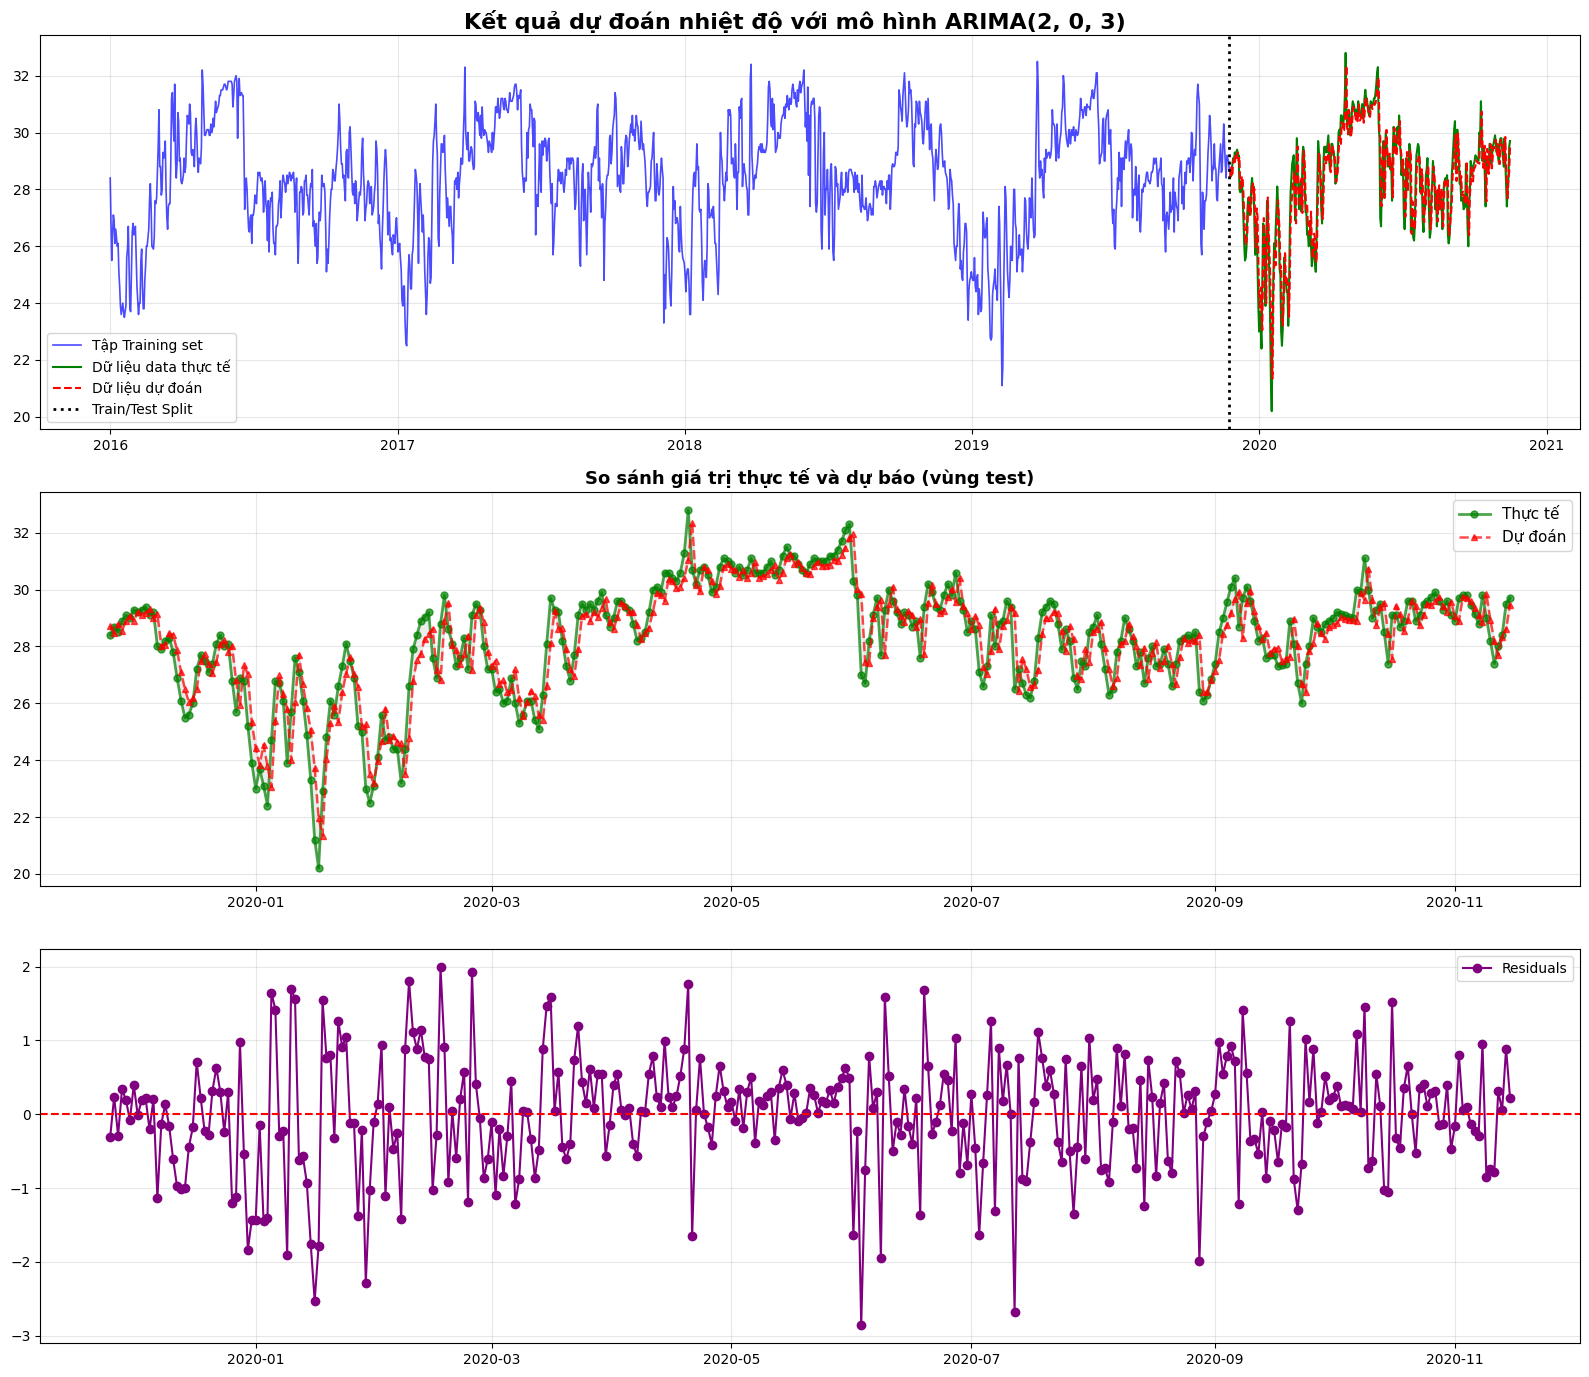

In [24]:
# Bước 5.5: Trực quan hóa kết quả dự báo

fig, axes = plt.subplots(3, 1, figsize=(16, 14))
fig.suptitle(f'Kết quả dự đoán nhiệt độ với mô hình ARIMA{best_params}', 
             fontsize=16, fontweight='bold')

# Plot 1: Toàn bộ chuỗi thời gian
axes[0].plot(train_data.index, train_data.values, label='Tập Training set', color='blue', linewidth=1.2, alpha=0.7)
axes[0].plot(test_data.index, test_data.values, label='Dữ liệu data thực tế', color='green', linewidth=1.5)
axes[0].plot(test_data.index, predictions, label='Dữ liệu dự đoán', color='red', linewidth=1.5, linestyle='--')
axes[0].axvline(x=train_data.index[-1], color='black', linestyle=':', linewidth=2, label='Train/Test Split')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Plot 2: Zoom test
axes[1].plot(test_data.index, test_data.values, 
             label='Thực tế', color='green', linewidth=2, 
             marker='o', markersize=5, alpha=0.7)

axes[1].plot(test_data.index, predictions, 
             label='Dự đoán', color='red', linewidth=1.8, 
             linestyle='--', marker='^', markersize=5, alpha=0.7)

# Làm rõ phần sai lệch giữa 2 đường
axes[1].fill_between(test_data.index,
                     test_data.values.squeeze(),
                     np.array(predictions).squeeze(),
                     alpha=0.15, color='gray')

axes[1].legend(loc='best', fontsize=11)
axes[1].set_title("So sánh giá trị thực tế và dự báo (vùng test)", fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Plot 3: Residuals(Phần dư)
residuals = np.array(test_data.values.squeeze()) - np.array(predictions).squeeze()
axes[2].plot(test_data.index, residuals, label='Residuals', color='purple', linewidth=1.5, marker='o')
axes[2].axhline(y=0, color='red', linestyle='--')
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

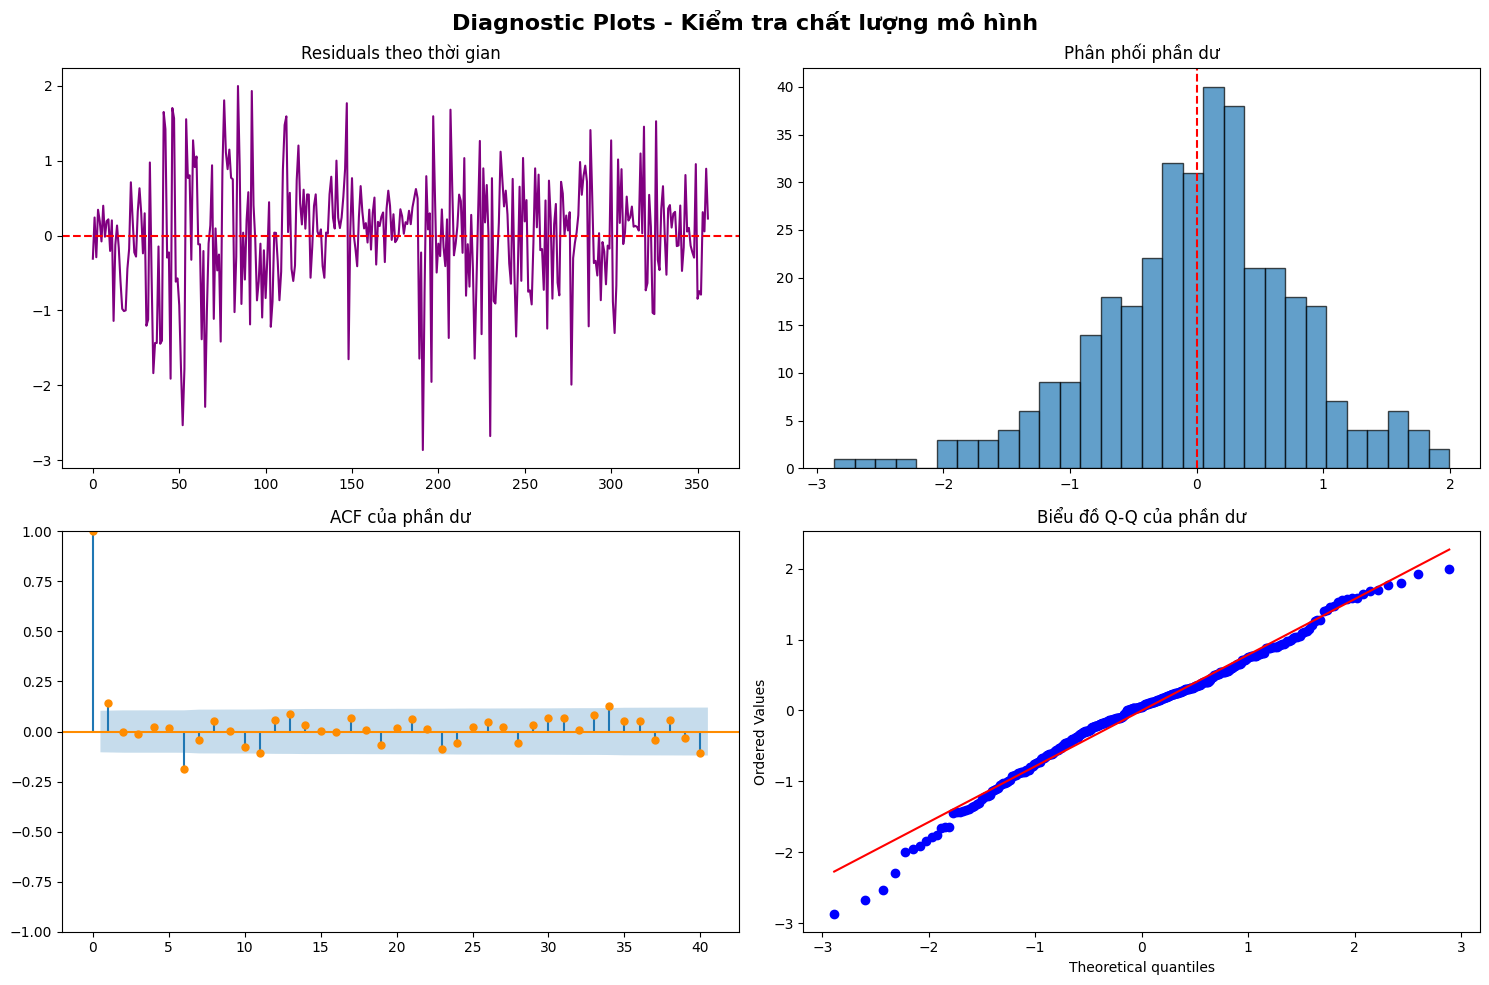

In [25]:
# Diagnostic plots - Kiểm tra chất lượng mô hình

residuals = pd.Series(residuals).dropna()

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Diagnostic Plots - Kiểm tra chất lượng mô hình', fontsize=16, fontweight='bold')

# Residuals theo thời gian
axes[0, 0].plot(residuals, color='purple')
axes[0, 0].axhline(y=0, color='red', linestyle='--')
axes[0, 0].set_title('Residuals theo thời gian')

# Histogram phần dư
axes[0, 1].hist(residuals, bins=30, edgecolor='black', alpha=0.7)
axes[0, 1].axvline(x=0, color='red', linestyle='--')
axes[0, 1].set_title('Phân phối phần dư')

# ACF phần dư
plot_acf(residuals, lags=40, ax=axes[1, 0], color='darkorange')
axes[1, 0].set_title('ACF của phần dư')

# Q-Q Plot
stats.probplot(residuals, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Biểu đồ Q-Q của phần dư')

plt.tight_layout()
plt.show()

Rolling Forecast Progress (Daily, có ngẫu nhiên)
Step 1/365: 2020-11-16 | Forecast = 29.13
Step 2/365: 2020-11-17 | Forecast = 28.52
Step 3/365: 2020-11-18 | Forecast = 27.58
Step 4/365: 2020-11-19 | Forecast = 27.14
Step 5/365: 2020-11-20 | Forecast = 26.99
Step 6/365: 2020-11-21 | Forecast = 28.11
Step 7/365: 2020-11-22 | Forecast = 28.22
Step 8/365: 2020-11-23 | Forecast = 27.55
Step 9/365: 2020-11-24 | Forecast = 27.64
Step 10/365: 2020-11-25 | Forecast = 27.92
Step 11/365: 2020-11-26 | Forecast = 27.53
Step 12/365: 2020-11-27 | Forecast = 26.68
Step 13/365: 2020-11-28 | Forecast = 27.27
Step 14/365: 2020-11-29 | Forecast = 27.10
Step 15/365: 2020-11-30 | Forecast = 27.16
Step 16/365: 2020-12-01 | Forecast = 26.59
Step 17/365: 2020-12-02 | Forecast = 27.57
Step 18/365: 2020-12-03 | Forecast = 26.61
Step 19/365: 2020-12-04 | Forecast = 25.73
Step 20/365: 2020-12-05 | Forecast = 27.13
Step 21/365: 2020-12-06 | Forecast = 28.02
Step 22/365: 2020-12-07 | Forecast = 27.98
Step 23/365: 2

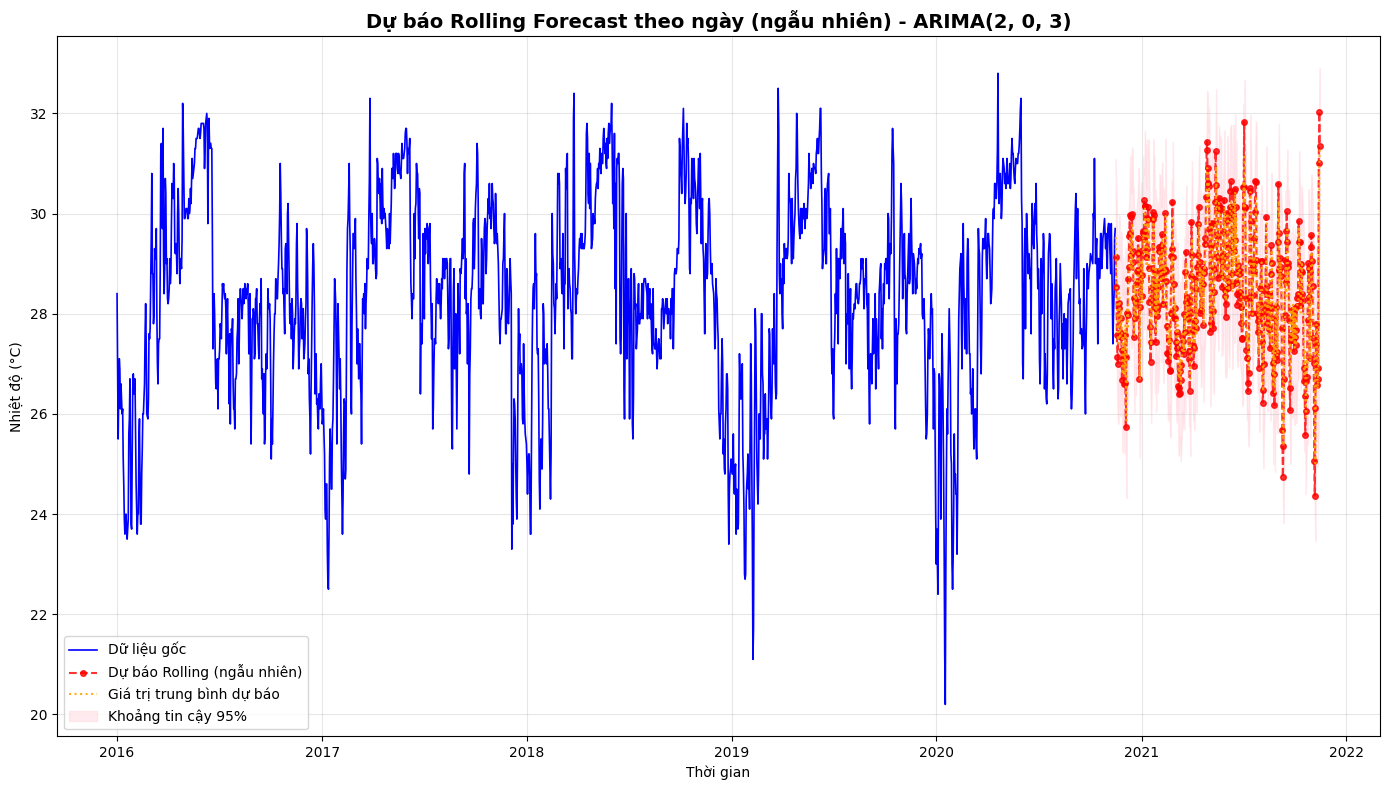

In [26]:
# Dự báo theo Rolling Forecast
forecast_steps = 365  # Số ngày muốn dự báo

rolling_data = data.copy()
rolling_forecasts = []

print("Rolling Forecast Progress (Daily, có ngẫu nhiên)")

for i in range(forecast_steps):
    try:
        model = ARIMA(rolling_data, order=best_params)
        fitted = model.fit()

        forecast_next = fitted.get_forecast(steps=1)
        pred_mean = forecast_next.predicted_mean.iloc[0]
        conf_int = forecast_next.conf_int().iloc[0]

        # Ước lượng độ lệch chuẩn từ khoảng tin cậy 95%
        sigma = (conf_int[1] - conf_int[0]) / (2 * 1.96)
        # Sinh giá trị ngẫu nhiên xung quanh trung bình dự báo
        forecast_value = np.random.normal(pred_mean, sigma)

        next_date = rolling_data.index[-1] + pd.DateOffset(days=1)
        rolling_forecasts.append({
            'Date': next_date,
            'Forecast': forecast_value,
            'Pred_Mean': pred_mean,
            'Lower CI': conf_int[0],
            'Upper CI': conf_int[1]
        })

        # Dùng giá trị ngẫu nhiên làm đầu vào cho bước kế tiếp
        rolling_data.loc[next_date] = forecast_value

        print(f"Step {i+1}/{forecast_steps}: {next_date.strftime('%Y-%m-%d')} | Forecast = {forecast_value:.2f}")

    except Exception as e:
        print(f"Lỗi tại bước {i+1}: {e}")
        break

rolling_df = pd.DataFrame(rolling_forecasts).set_index('Date')

print("\nKết quả Rolling Forecast (Daily, ngẫu nhiên)")
print(rolling_df.head())

# Sau khi chạy xong đoạn Rolling Forecast (ngẫu nhiên)
plt.figure(figsize=(14, 8))

# Dữ liệu gốc
plt.plot(data, label='Dữ liệu gốc', color='blue', linewidth=1.2)

# Dự báo rolling
plt.plot(rolling_df['Forecast'], label='Dự báo Rolling (ngẫu nhiên)', 
         color='red', linestyle='--', marker='o', markersize=4, alpha=0.8)

# Đường dự báo trung bình (tùy chọn, giúp so sánh độ mượt)
plt.plot(rolling_df['Pred_Mean'], label='Giá trị trung bình dự báo', 
         color='orange', linestyle=':', linewidth=1.5, alpha=0.9)

# Khoảng tin cậy
plt.fill_between(rolling_df.index, 
                 rolling_df['Lower CI'], rolling_df['Upper CI'], 
                 color='pink', alpha=0.3, label='Khoảng tin cậy 95%')

plt.title(f'Dự báo Rolling Forecast theo ngày (ngẫu nhiên) - ARIMA{best_params}', 
          fontsize=14, fontweight='bold')
plt.xlabel('Thời gian')
plt.ylabel('Nhiệt độ (°C)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Mô hình ARIMA(1,0,0)

In [27]:
print("BƯỚC 5.2: HUẤN LUYỆN MÔ HÌNH ARIMA(1, 0, 0)")

# Xác định bộ tham số cố định
params1 = (1, 0, 0)

print(f"\nĐang huấn luyện mô hình ARIMA{params1}...")

# Fit mô hình ARIMA với dữ liệu huấn luyện
model_ar1 = ARIMA(train_data, order=params1)
ar1_fitted = model_ar1.fit()

# Hiển thị thông tin mô hình
print(f"Các thông số của mô hình ARIMA{params1}:")
print(ar1_fitted.summary())

# Lưu lại mô hình đã fit để dùng cho bước Rolling Forecast
params1 = params1


BƯỚC 5.2: HUẤN LUYỆN MÔ HÌNH ARIMA(1, 0, 0)

Đang huấn luyện mô hình ARIMA(1, 0, 0)...
Các thông số của mô hình ARIMA(1, 0, 0):
                               SARIMAX Results                                
Dep. Variable:                   temp   No. Observations:                 1424
Model:                 ARIMA(1, 0, 0)   Log Likelihood               -1736.822
Date:                Fri, 07 Nov 2025   AIC                           3479.644
Time:                        09:47:08   BIC                           3495.428
Sample:                    01-01-2016   HQIC                          3485.540
                         - 11-24-2019                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         28.3612      0.244    116.059      0.000      27.882      28.840
ar.

In [28]:
preds1 = []
model1 = ARIMA(test_data, order=(1,0,0)).fit()

for t in range(len(test_data)):
    yhat1 = model1.forecast()[0]  # Dự báo một bước
    preds1.append(yhat1)
    model1 = model1.append([test_data.iloc[t]], refit=False)  # Cập nhật dữ liệu

predictions1 = pd.Series(preds1, index=test_data.index)
print("Rolling Forecast đã hoàn tất")

Rolling Forecast đã hoàn tất


In [29]:
mse1 = mean_squared_error(test_data, predictions1)
rmse1 = np.sqrt(mse)
mae1 = mean_absolute_error(test_data, predictions1)
mape1 = mean_absolute_percentage_error(test_data, predictions1) * 100
r21 = r2_score(test_data, predictions1)


print("Bước 5.4 Đánh giá mô hình")
print(f"Mean Squared Error (MSE):  {mse1:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse1:.4f} °C")
print(f"Mean Absolute Error (MAE): {mae1:.4f} °C")
print(f"Mean Absolute Percentage Error (MAPE): {mape1:.2f}%")
print(f"R² (Coefficient of Determination): {r21:.4f}")

Bước 5.4 Đánh giá mô hình
Mean Squared Error (MSE):  0.6694
Root Mean Squared Error (RMSE): 0.7870 °C
Mean Absolute Error (MAE): 0.6273 °C
Mean Absolute Percentage Error (MAPE): 2.29%
R² (Coefficient of Determination): 0.8261


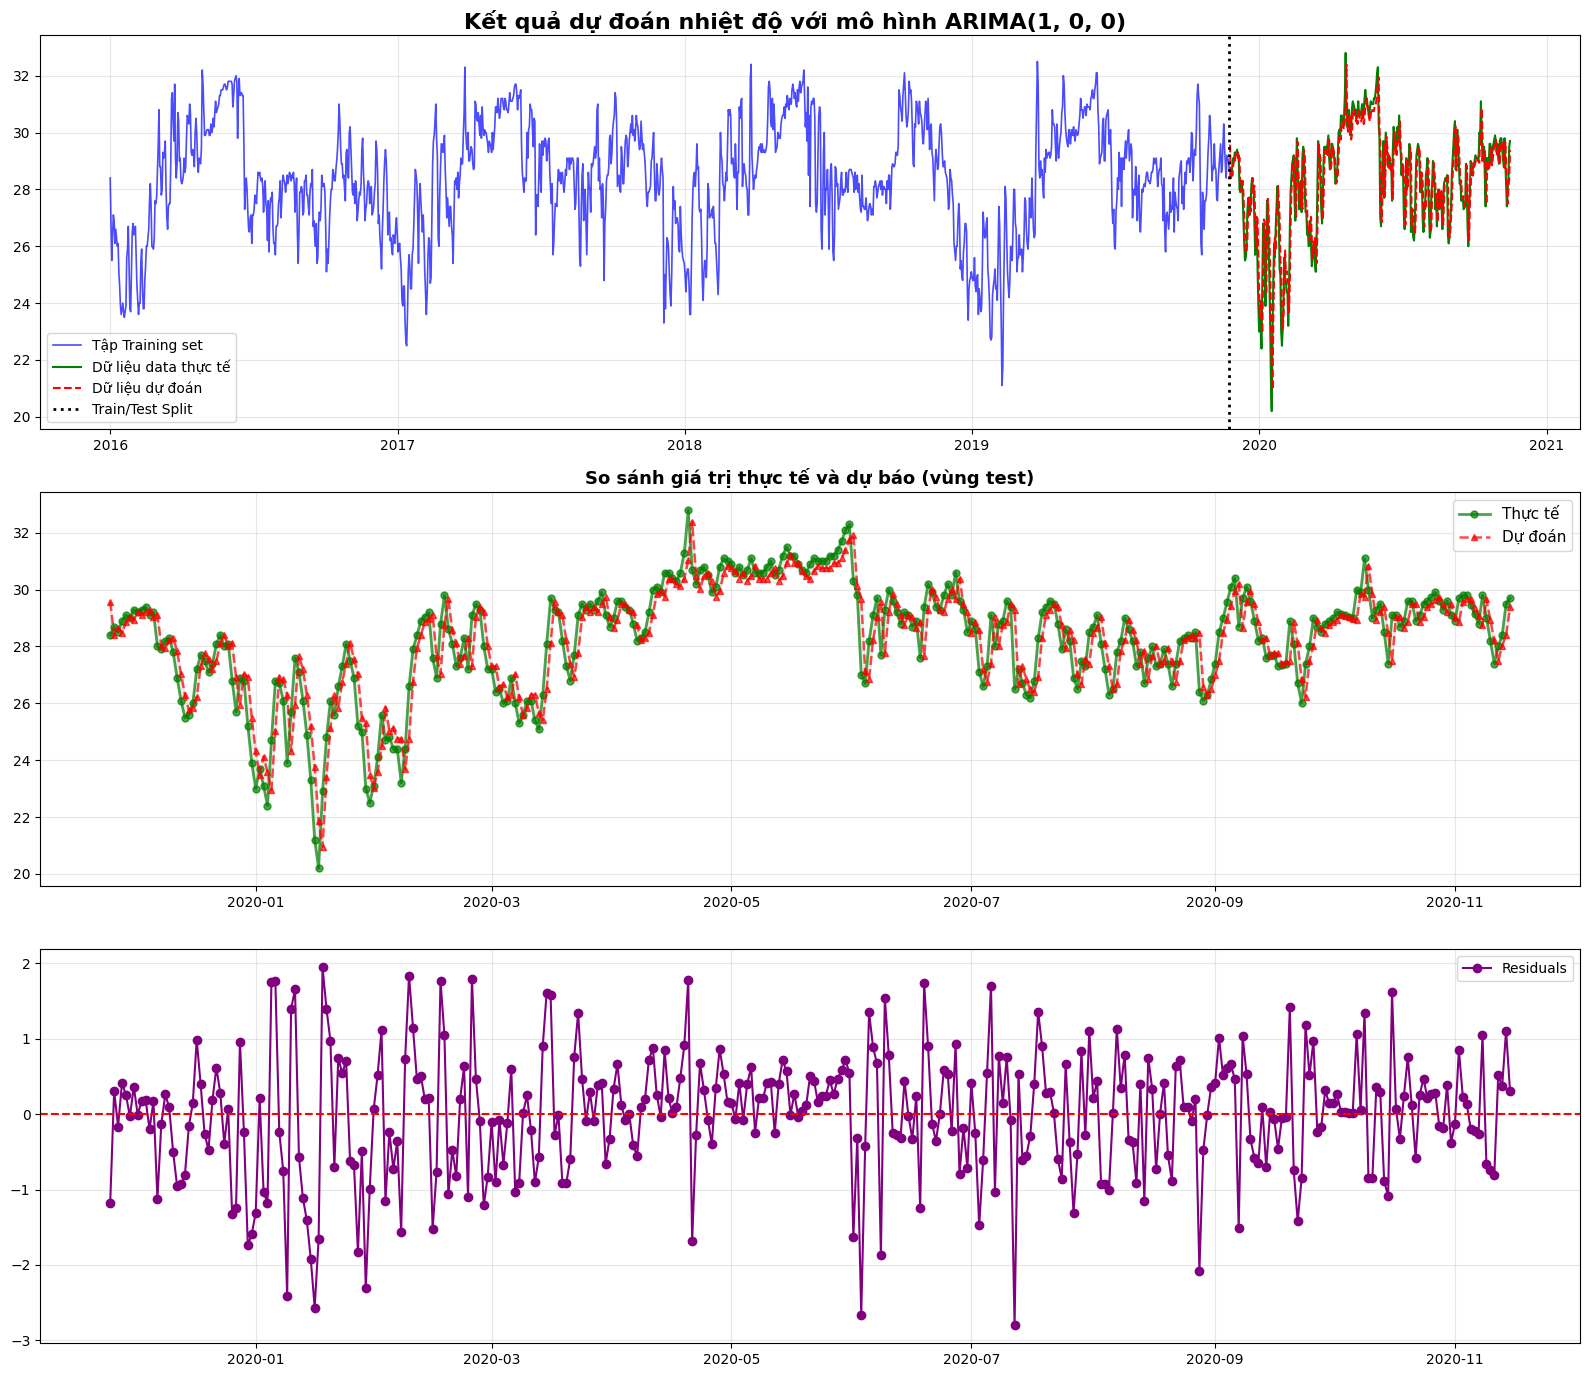

In [30]:
# Bước 5.5: Trực quan hóa kết quả dự báo

fig1, axes1 = plt.subplots(3, 1, figsize=(16, 14))
fig1.suptitle(f'Kết quả dự đoán nhiệt độ với mô hình ARIMA{params1}',
             fontsize=16, fontweight='bold')

# Plot 1: Toàn bộ chuỗi thời gian
axes1[0].plot(train_data.index, train_data.values, label='Tập Training set', color='blue', linewidth=1.2, alpha=0.7)
axes1[0].plot(test_data.index, test_data.values, label='Dữ liệu data thực tế', color='green', linewidth=1.5)
axes1[0].plot(test_data.index, predictions1, label='Dữ liệu dự đoán', color='red', linewidth=1.5, linestyle='--')
axes1[0].axvline(x=train_data.index[-1], color='black', linestyle=':', linewidth=2, label='Train/Test Split')
axes1[0].legend(); axes1[0].grid(True, alpha=0.3)

# Plot 2: Zoom test
axes1[1].plot(test_data.index, test_data.values,
             label='Thực tế', color='green', linewidth=2,
             marker='o', markersize=5, alpha=0.7)

axes1[1].plot(test_data.index, predictions1,
             label='Dự đoán', color='red', linewidth=1.8,
             linestyle='--', marker='^', markersize=5, alpha=0.7)

# Làm rõ phần sai lệch giữa 2 đường
axes1[1].fill_between(test_data.index,
                     test_data.values.squeeze(),
                     np.array(predictions1).squeeze(),
                     alpha=0.15, color='gray')

axes1[1].legend(loc='best', fontsize=11)
axes1[1].set_title("So sánh giá trị thực tế và dự báo (vùng test)", fontsize=13, fontweight='bold')
axes1[1].grid(True, alpha=0.3)

# Plot 3: Residuals(Phần dư)
residuals1 = np.array(test_data.values.squeeze()) - np.array(predictions1).squeeze()
axes1[2].plot(test_data.index, residuals1, label='Residuals', color='purple', linewidth=1.5, marker='o')
axes1[2].axhline(y=0, color='red', linestyle='--')
axes1[2].legend(); axes1[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

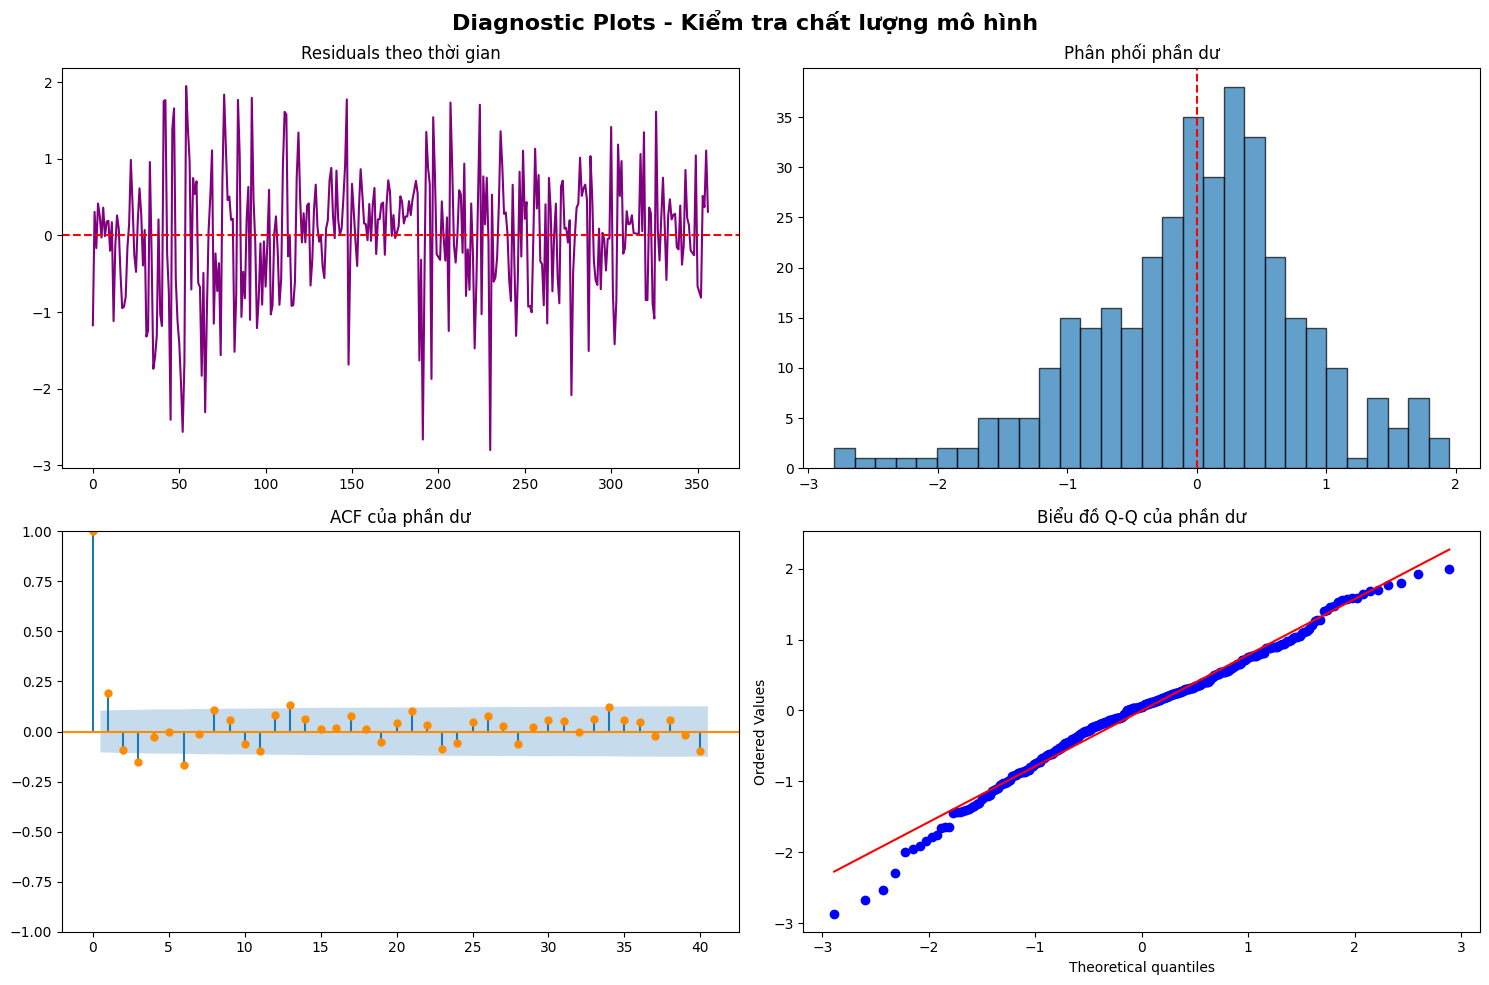

In [31]:
residuals1 = pd.Series(residuals1).dropna()

fig1, axes1 = plt.subplots(2, 2, figsize=(15, 10))
fig1.suptitle('Diagnostic Plots - Kiểm tra chất lượng mô hình', fontsize=16, fontweight='bold')

# Residuals theo thời gian
axes1[0, 0].plot(residuals1, color='purple')
axes1[0, 0].axhline(y=0, color='red', linestyle='--')
axes1[0, 0].set_title('Residuals theo thời gian')

# Histogram phần dư
axes1[0, 1].hist(residuals1, bins=30, edgecolor='black', alpha=0.7)
axes1[0, 1].axvline(x=0, color='red', linestyle='--')
axes1[0, 1].set_title('Phân phối phần dư')

# ACF phần dư
plot_acf(residuals1, lags=40, ax=axes1[1, 0], color='darkorange')
axes1[1, 0].set_title('ACF của phần dư')

# Q-Q Plot
stats.probplot(residuals, dist="norm", plot=axes1[1, 1])
axes1[1, 1].set_title('Biểu đồ Q-Q của phần dư')

plt.tight_layout()
plt.show()

Rolling Forecast Progress (Daily, có ngẫu nhiên)
Step 1/365: 2020-11-16 | Forecast = 28.66
Step 2/365: 2020-11-17 | Forecast = 26.61
Step 3/365: 2020-11-18 | Forecast = 27.17
Step 4/365: 2020-11-19 | Forecast = 26.65
Step 5/365: 2020-11-20 | Forecast = 27.63
Step 6/365: 2020-11-21 | Forecast = 27.92
Step 7/365: 2020-11-22 | Forecast = 27.69
Step 8/365: 2020-11-23 | Forecast = 28.34
Step 9/365: 2020-11-24 | Forecast = 27.41
Step 10/365: 2020-11-25 | Forecast = 26.62
Step 11/365: 2020-11-26 | Forecast = 25.31
Step 12/365: 2020-11-27 | Forecast = 26.09
Step 13/365: 2020-11-28 | Forecast = 25.65
Step 14/365: 2020-11-29 | Forecast = 26.09
Step 15/365: 2020-11-30 | Forecast = 25.14
Step 16/365: 2020-12-01 | Forecast = 25.29
Step 17/365: 2020-12-02 | Forecast = 27.83
Step 18/365: 2020-12-03 | Forecast = 28.35
Step 19/365: 2020-12-04 | Forecast = 29.03
Step 20/365: 2020-12-05 | Forecast = 29.41
Step 21/365: 2020-12-06 | Forecast = 29.52
Step 22/365: 2020-12-07 | Forecast = 29.94
Step 23/365: 2

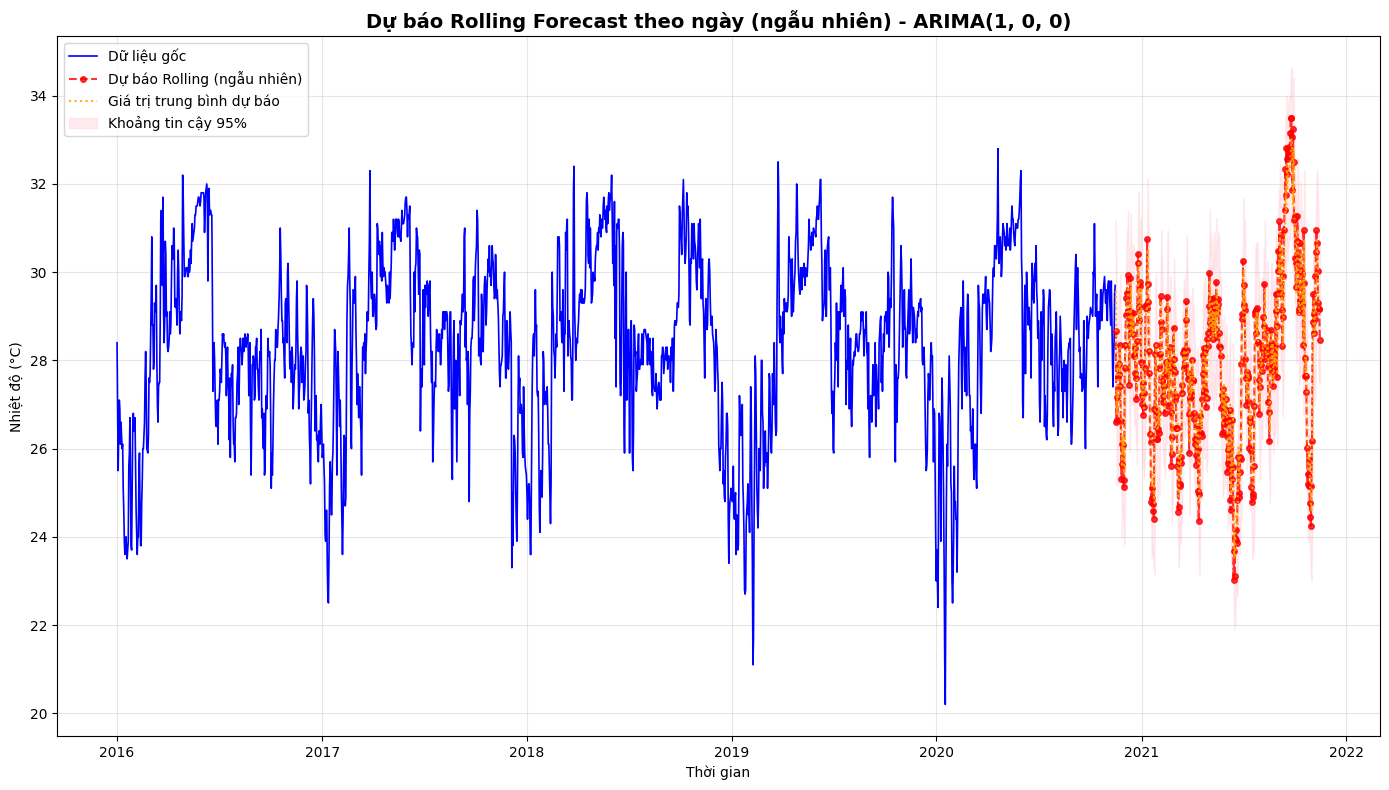

In [32]:
# Dự báo theo Rolling Forecast (có ngẫu nhiên)
forecast_steps = 365  # số ngày muốn dự báo

rolling_data1 = data.copy()
rolling_forecasts1 = []

print("Rolling Forecast Progress (Daily, có ngẫu nhiên)")

for i in range(forecast_steps):
    try:
        model1 = ARIMA(rolling_data1, order=params1)
        fitted1 = model1.fit()

        forecast_next1 = fitted1.get_forecast(steps=1)
        pred_mean1 = forecast_next1.predicted_mean.iloc[0]
        conf_int1 = forecast_next1.conf_int().iloc[0]

        # Ước lượng độ lệch chuẩn từ khoảng tin cậy 95%
        sigma1 = (conf_int1[1] - conf_int1[0]) / (2 * 1.96)
        # Sinh giá trị ngẫu nhiên xung quanh trung bình dự báo
        forecast_value1 = np.random.normal(pred_mean1, sigma1)

        next_date1 = rolling_data1.index[-1] + pd.DateOffset(days=1)
        rolling_forecasts1.append({
            'Date': next_date1,
            'Forecast': forecast_value1,
            'Pred_Mean': pred_mean1,
            'Lower CI': conf_int1[0],
            'Upper CI': conf_int1[1]
        })

        # Dùng giá trị ngẫu nhiên làm đầu vào cho bước kế tiếp
        rolling_data1.loc[next_date1] = forecast_value1

        print(f"Step {i+1}/{forecast_steps}: {next_date1.strftime('%Y-%m-%d')} | Forecast = {forecast_value1:.2f}")

    except Exception as e:
        print(f"Lỗi tại bước {i+1}: {e}")
        break

rolling_df1 = pd.DataFrame(rolling_forecasts1).set_index('Date')

print("\nKết quả Rolling Forecast (Daily, ngẫu nhiên)")
print(rolling_df1.head())

# Sau khi chạy xong đoạn Rolling Forecast (ngẫu nhiên)
plt.figure(figsize=(14, 8))

# Dữ liệu gốc
plt.plot(data, label='Dữ liệu gốc', color='blue', linewidth=1.2)

# Dự báo rolling
plt.plot(rolling_df1['Forecast'], label='Dự báo Rolling (ngẫu nhiên)', 
         color='red', linestyle='--', marker='o', markersize=4, alpha=0.8)

# Đường dự báo trung bình (tùy chọn, giúp so sánh độ mượt)
plt.plot(rolling_df1['Pred_Mean'], label='Giá trị trung bình dự báo', 
         color='orange', linestyle=':', linewidth=1.5, alpha=0.9)

# Khoảng tin cậy
plt.fill_between(rolling_df1.index, 
                 rolling_df1['Lower CI'], rolling_df1['Upper CI'], 
                 color='pink', alpha=0.3, label='Khoảng tin cậy 95%')

# Trang trí
plt.title(f'Dự báo Rolling Forecast theo ngày (ngẫu nhiên) - ARIMA{params1}', 
          fontsize=14, fontweight='bold')
plt.xlabel('Thời gian')
plt.ylabel('Nhiệt độ (°C)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**SO SÁNH MÔ HÌNH ARIMA**

**So sánh với Random Forest**

Kích thước dữ liệu:
- Tổng số quan sát: 1781
- Training set: 1424 mẫu (80.0%)
- Test set: 357 mẫu (20.0%)

Đánh giá mô hình Random Forest
Mean Squared Error (MSE):  0.6718
Root Mean Squared Error (RMSE): 0.8196 °C
Mean Absolute Error (MAE): 0.6164 °C
Mean Absolute Percentage Error (MAPE): 2.24%
R² (Coefficient of Determination): 0.8269


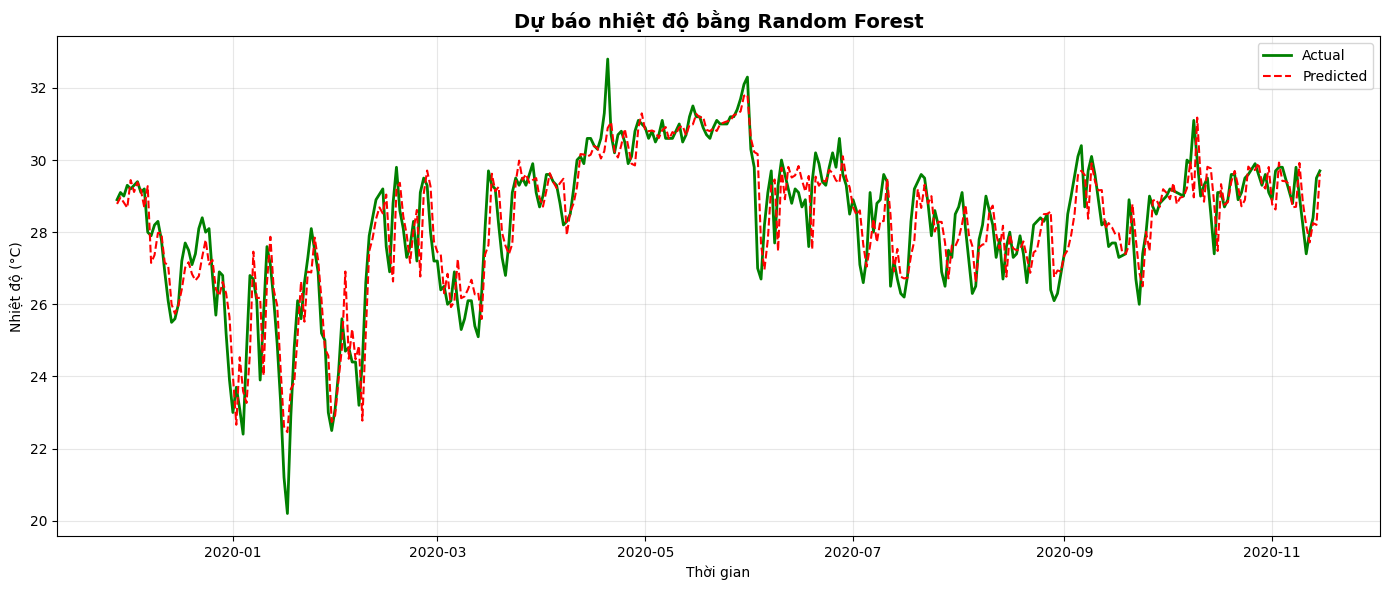

In [33]:
# Bước 1: Chia tập dữ liệu thành train và test
train_data, test_data = train_test_split(data, test_size=0.2, shuffle=False)

print(f"Kích thước dữ liệu:")
print(f"- Tổng số quan sát: {len(data)}")
print(f"- Training set: {len(train_data)} mẫu ({len(train_data)/len(data)*100:.1f}%)")
print(f"- Test set: {len(test_data)} mẫu ({len(test_data)/len(data)*100:.1f}%)")

# Bước 2: Tạo tập đặc trưng (Features)
# Vì Random Forest không làm việc trực tiếp với chuỗi thời gian nên ta tạo thêm các đặc trưng thời gian từ index
def create_features(df):
    df = df.copy()
    df['month'] = df.index.month
    df['year'] = df.index.year
    df['day'] = df.index.dayofyear
    df['lag1'] = df['temp'].shift(1)
    df['lag2'] = df['temp'].shift(2)
    df['lag3'] = df['temp'].shift(3)
    return df.dropna()

train_feat = create_features(train_data)
test_feat = create_features(test_data)

X_train = train_feat[['month', 'year', 'day', 'lag1', 'lag2', 'lag3']]
y_train = train_feat['temp']

X_test = test_feat[['month', 'year', 'day', 'lag1', 'lag2', 'lag3']]
y_test = test_feat['temp']

# Bước 3: Huấn luyện mô hình random forest

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    max_depth=None,
    min_samples_split=2
)
model.fit(X_train, y_train)

# Bước 4: Dự đoán và đánh giá mô hình

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred) * 100
r2 = r2_score(y_test, y_pred)

print("\nĐánh giá mô hình Random Forest")
print(f"Mean Squared Error (MSE):  {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f} °C")
print(f"Mean Absolute Error (MAE): {mae:.4f} °C")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")
print(f"R² (Coefficient of Determination): {r2:.4f}")

# Bước 5: Trực quan kết quả dự đoán bằng Random Forest
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))
plt.plot(y_test.index, y_test.values, label='Actual', color='green', linewidth=2)
plt.plot(y_test.index, y_pred, label='Predicted', color='red', linestyle='--')
plt.title('Dự báo nhiệt độ bằng Random Forest', fontsize=14, fontweight='bold')
plt.xlabel('Thời gian'); plt.ylabel('Nhiệt độ (°C)')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()